# Sistema Fuzzy Takagi-Sugeno para Aproximação de Função Não Linear

Implementação de um sistema fuzzy Takagi-Sugeno (ordem zero e primeira ordem) para aproximar $f(x) = e^{-x/5} \cdot \sin(3x) + 0.5 \cdot \sin(x)$ no intervalo $x \in [0, 10]$.

## 1. Geração do conjunto de dados

Gerando 200 pontos uniformemente espaçados no intervalo [0, 10] e calculando $f(x)$.

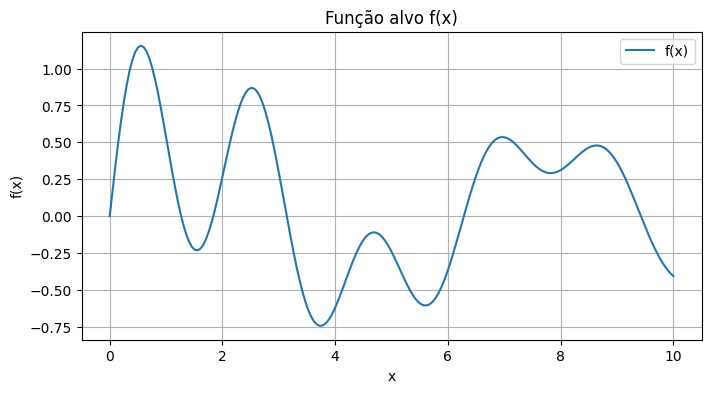

In [1]:
# Importa a biblioteca NumPy para operações matemáticas e de arrays
import numpy as np
# Importa a biblioteca Matplotlib para geração de gráficos
import matplotlib.pyplot as plt
# Importa a biblioteca os para manipulação de diretórios
import os

# Gera 200 pontos uniformemente espaçados no intervalo de 0 a 10
x = np.linspace(0, 10, 200)
# Calcula os valores da função alvo f(x) para cada ponto de x
fx = np.exp(-x/5) * np.sin(3*x) + 0.5 * np.sin(x)

# Cria uma nova figura para o gráfico com tamanho 8x4 polegadas
plt.figure(figsize=(8,4))
# Plota a curva de f(x) em função de x
plt.plot(x, fx, label='f(x)')
# Define o título do gráfico
plt.title('Função alvo f(x)')
# Define o rótulo do eixo x
plt.xlabel('x')
# Define o rótulo do eixo y
plt.ylabel('f(x)')
# Exibe a legenda do gráfico
plt.legend()
# Adiciona uma grade ao gráfico
plt.grid(True)
# Verifica se o diretório "img" existe; se não existir, cria o diretório
if not os.path.exists("img"):
    os.makedirs("img")
# Salva o gráfico gerado como uma imagem PNG no diretório "img"
plt.savefig("img/fx_takagi_sugeno2.png")
# Exibe o gráfico na tela
plt.show()

## 2. Estrutura do Sistema Fuzzy Takagi-Sugeno

- Variável de entrada: $x \in [0, 10]$
- Saída: $y \approx f(x)$
- 3 regras (Baixo, Médio, Alto)
- Funções de pertinência: gaussianas, triangulares e trapezoidais
- Consequentes: constantes (ordem zero) ou lineares (primeira ordem)
- Operador de agregação: soma ponderada pelas pertinências

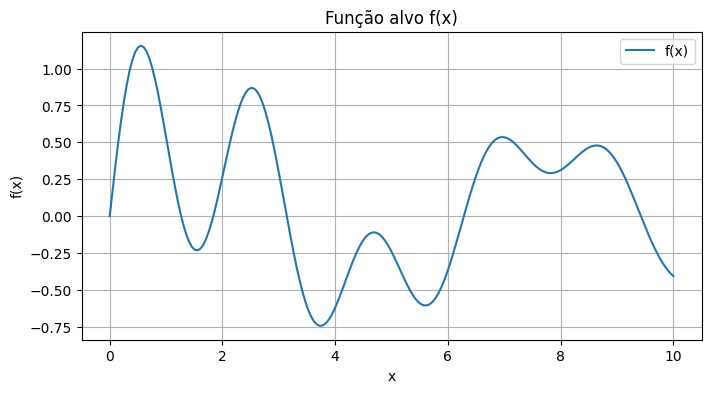

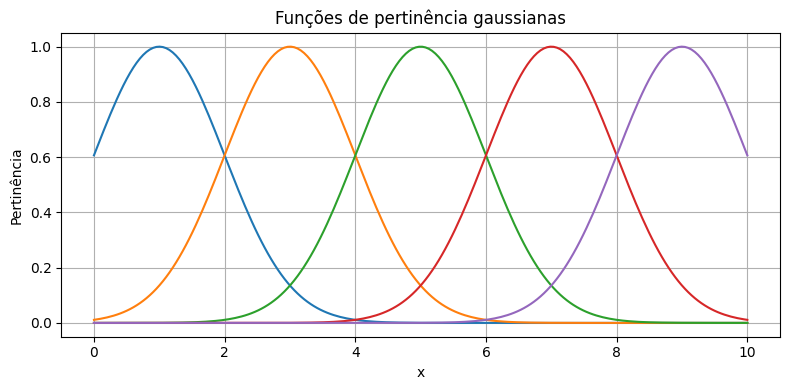

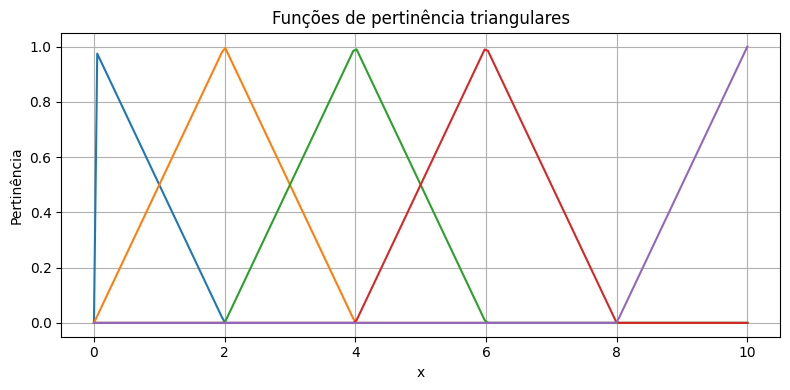

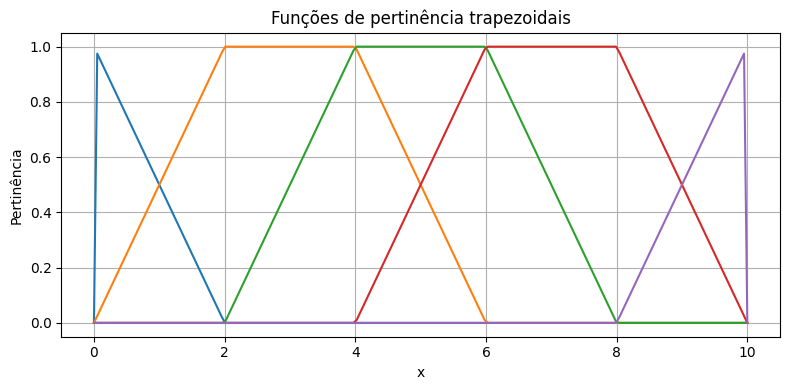

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Geração do conjunto de dados
x = np.linspace(0, 10, 200)
fx = np.exp(-x/5) * np.sin(3*x) + 0.5 * np.sin(x)

plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x)')
plt.title('Função alvo f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
if not os.path.exists("img"):
    os.makedirs("img")
plt.savefig("img/fx_takagi_sugeno2.png")
plt.show()

# 2. Funções de pertinência e parâmetros
def gaussmf(x, c, sigma):
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)

def trimf(x, a, b, c):
    x = np.asarray(x)
    y = np.zeros_like(x)
    idx1 = (a < x) & (x <= b)
    y[idx1] = (x[idx1] - a) / (b - a + 1e-9)
    idx2 = (b < x) & (x < c)
    y[idx2] = (c - x[idx2]) / (c - b + 1e-9)
    return np.clip(y, 0, 1)

def trapmf(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x-a)/(b-a+1e-9), 1), (d-x)/(d-c+1e-9)), 0)

def gerar_parametros_mfs(x, n_mfs):
    edges = np.linspace(x[0], x[-1], n_mfs+1)
    centros = (edges[:-1] + edges[1:]) / 2
    sigmas = np.repeat((edges[1] - edges[0])/2, n_mfs)
    # Triangulares
    mf_params_tri = []
    for i in range(n_mfs):
        if i == 0:
            mf_params_tri.append((x[0], edges[0], edges[1]))
        elif i == n_mfs-1:
            mf_params_tri.append((edges[-2], edges[-1], x[-1]))
        else:
            mf_params_tri.append((edges[i-1], edges[i], edges[i+1]))
    # Trapezoidais
    mf_params_trap = []
    for i in range(n_mfs):
        if i == 0:
            mf_params_trap.append((x[0], x[0], edges[0], edges[1]))
        elif i == n_mfs-1:
            mf_params_trap.append((edges[-2], edges[-1], x[-1], x[-1]))
        else:
            mf_params_trap.append((edges[i-1], edges[i], edges[i+1], edges[i+2]))
    return centros, sigmas, mf_params_tri, mf_params_trap

n_mfs = 5
centros, sigmas, mf_params_tri, mf_params_trap = gerar_parametros_mfs(x, n_mfs)

# Listas de pertinência para cada tipo
mus_gauss = [gaussmf(x, c, s) for c, s in zip(centros, sigmas)]
mus_tri = [trimf(x, *p) for p in mf_params_tri]
mus_trap = [trapmf(x, *p) for p in mf_params_trap]

# Salva as imagens das funções de pertinência com o valor de n_mfs no nome do arquivo

# Gaussianas
plt.figure(figsize=(8,4))
for mu in mus_gauss:
    plt.plot(x, mu)
plt.title('Funções de pertinência gaussianas')
plt.xlabel('x')
plt.ylabel('Pertinência')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"img/funcoes_de_pertinencia_gaussianas_{n_mfs}.png", dpi=300)
plt.show()

# Triangulares
plt.figure(figsize=(8,4))
for mu in mus_tri:
    plt.plot(x, mu)
plt.title('Funções de pertinência triangulares')
plt.xlabel('x')
plt.ylabel('Pertinência')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"img/funcoes_de_pertinencia_triangulares_{n_mfs}.png", dpi=300)
plt.show()

# Trapezoidais
plt.figure(figsize=(8,4))
for mu in mus_trap:
    plt.plot(x, mu)
plt.title('Funções de pertinência trapezoidais')
plt.xlabel('x')
plt.ylabel('Pertinência')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"img/funcoes_de_pertinencia_trapezoidais_{n_mfs}.png", dpi=300)
plt.show()

## 3. Takagi-Sugeno de Ordem Zero

Cada regra tem consequente constante. A saída é a média ponderada dos consequentes pelas pertinências.

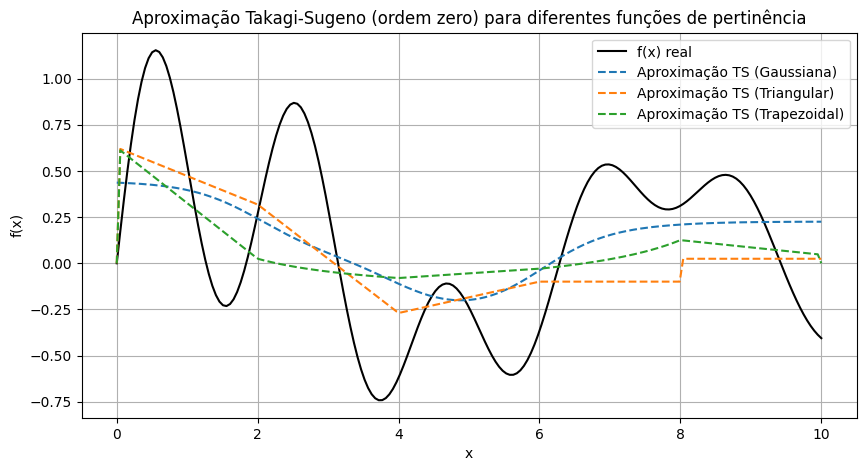

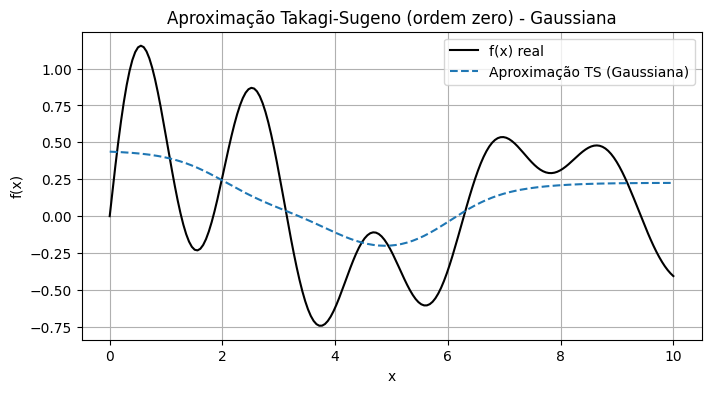

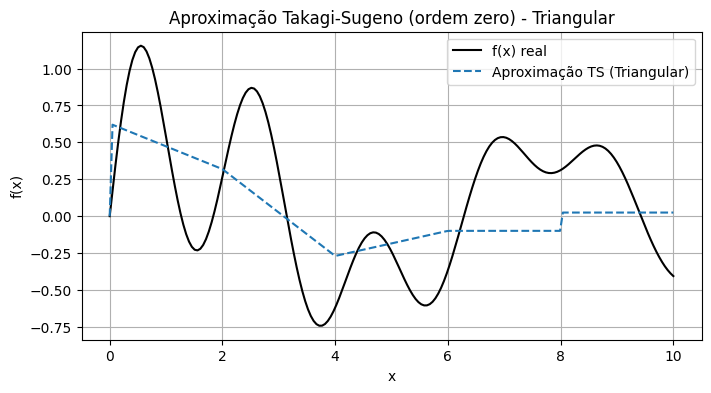

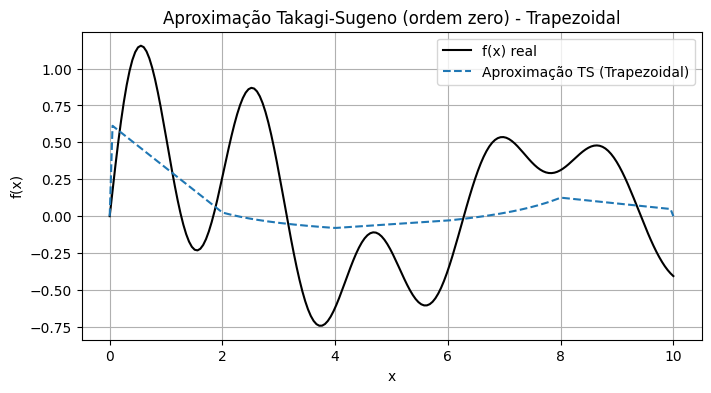

In [3]:
# 3. Takagi-Sugeno de Ordem Zero
def ts_zero(x, mus, consequentes):
    num = np.zeros_like(x)
    den = np.zeros_like(x)
    for mu, c in zip(mus, consequentes):
        num += mu * c
        den += mu
    return num / (den + 1e-8)

def get_consequentes(mus, fx):
    return [np.sum((mu / (np.sum(mu) + 1e-8)) * fx) for mu in mus]

# Gaussianas
conseq_gauss = get_consequentes(mus_gauss, fx)
fx_gauss_prod = ts_zero(x, mus_gauss, conseq_gauss)
# Triangulares
conseq_tri = get_consequentes(mus_tri, fx)
fx_tri_prod = ts_zero(x, mus_tri, conseq_tri)
# Trapezoidais
conseq_trap = get_consequentes(mus_trap, fx)
fx_trap_prod = ts_zero(x, mus_trap, conseq_trap)

# Salva os gráficos incluindo o valor de n_mfs no nome dos arquivos

# Plot geral para todas as funções de pertinência
plt.figure(figsize=(10,5))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_prod, '--', label='Aproximação TS (Gaussiana)')
plt.plot(x, fx_tri_prod, '--', label='Aproximação TS (Triangular)')
plt.plot(x, fx_trap_prod, '--', label='Aproximação TS (Trapezoidal)')
plt.title('Aproximação Takagi-Sugeno (ordem zero) para diferentes funções de pertinência')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_ordem_zero_todas_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Plot para Gaussiana
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_prod, '--', label='Aproximação TS (Gaussiana)')
plt.title('Aproximação Takagi-Sugeno (ordem zero) - Gaussiana')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_ordem_zero_gaussiana_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Plot para Triangular
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_tri_prod, '--', label='Aproximação TS (Triangular)')
plt.title('Aproximação Takagi-Sugeno (ordem zero) - Triangular')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_ordem_zero_triangular_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Plot para Trapezoidal
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_trap_prod, '--', label='Aproximação TS (Trapezoidal)')
plt.title('Aproximação Takagi-Sugeno (ordem zero) - Trapezoidal')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_ordem_zero_trapezoidal_takagi_sugeno2_{n_mfs}.png")
plt.show()

## 4. Takagi-Sugeno de Primeira Ordem

Cada regra tem consequente linear: $y = a_i x + b_i$. Ajuste por mínimos quadrados ponderados.

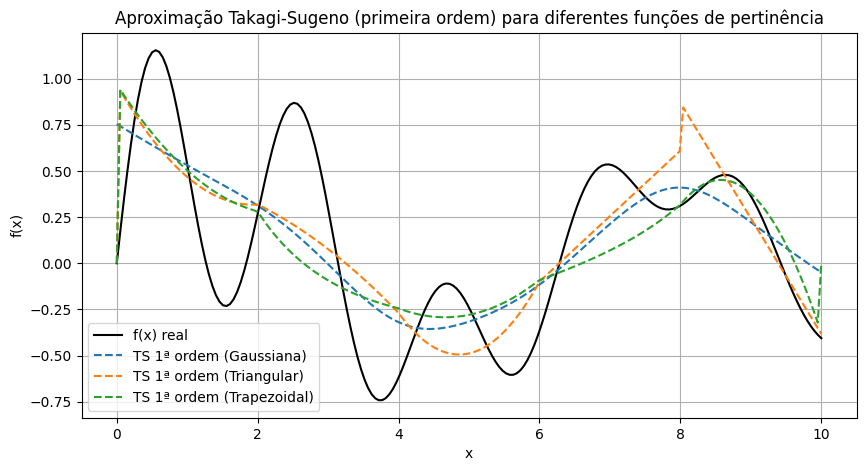

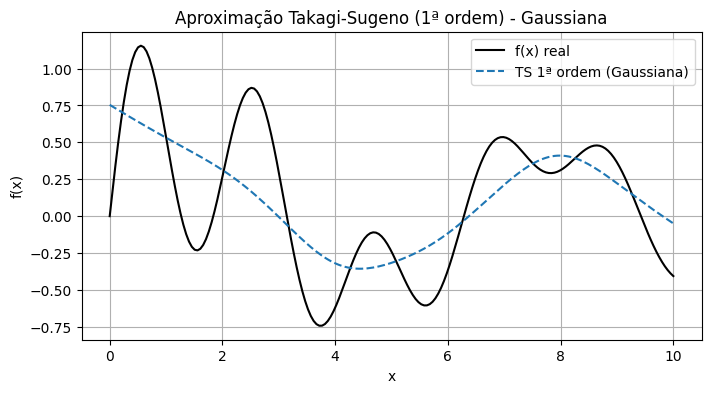

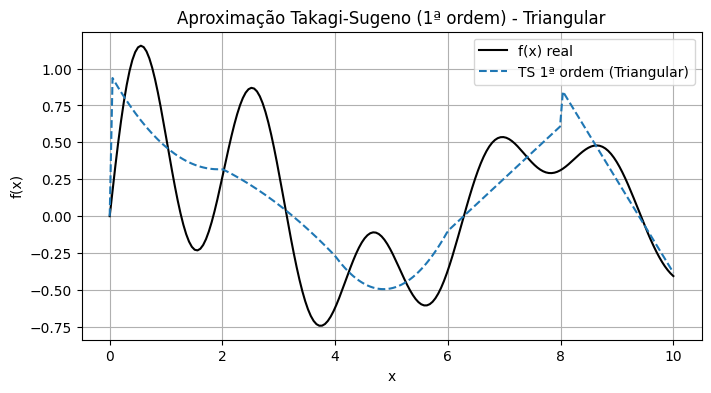

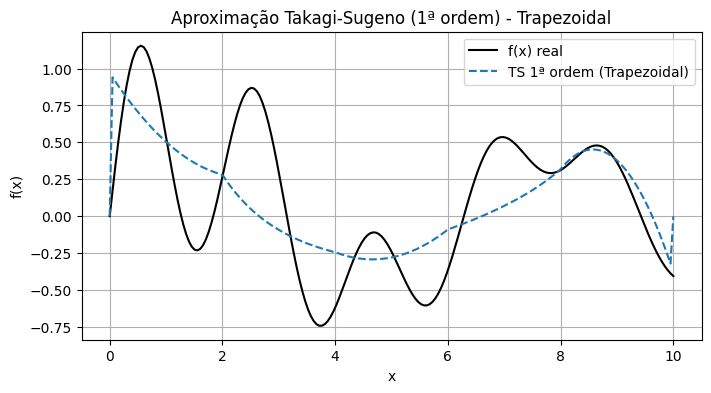

In [4]:
# 4. Takagi-Sugeno de Primeira Ordem para todas as funções de pertinência

def ts_primeira_ordem(x, mus, params):
    num = np.zeros_like(x)
    den = np.zeros_like(x)
    for mu, (a, b) in zip(mus, params):
        num += mu * (a * x + b)
        den += mu
    return num / (den + 1e-8)

def get_params_primeira_ordem(x, mus, fx):
    params = []
    for mu in mus:
        Xmat = np.vstack([x, np.ones_like(x)]).T
        W = np.diag(mu)
        XtWX = Xmat.T @ W @ Xmat
        XtWy = Xmat.T @ W @ fx
        ab = np.linalg.solve(XtWX, XtWy)
        params.append(ab)
    return params

# Gaussianas
params_gauss = get_params_primeira_ordem(x, mus_gauss, fx)
fx_gauss_1ordem = ts_primeira_ordem(x, mus_gauss, params_gauss)

# Triangulares
params_tri = get_params_primeira_ordem(x, mus_tri, fx)
fx_tri_1ordem = ts_primeira_ordem(x, mus_tri, params_tri)

# Trapezoidais
params_trap = get_params_primeira_ordem(x, mus_trap, fx)
fx_trap_1ordem = ts_primeira_ordem(x, mus_trap, params_trap)

# Salva os gráficos incluindo o valor de n_mfs no nome dos arquivos

# Plot geral para todas as funções de pertinência (primeira ordem)
plt.figure(figsize=(10,5))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_1ordem, '--', label='TS 1ª ordem (Gaussiana)')
plt.plot(x, fx_tri_1ordem, '--', label='TS 1ª ordem (Triangular)')
plt.plot(x, fx_trap_1ordem, '--', label='TS 1ª ordem (Trapezoidal)')
plt.title('Aproximação Takagi-Sugeno (primeira ordem) para diferentes funções de pertinência')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_1ordem_todas_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Plot para Gaussiana (primeira ordem)
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_1ordem, '--', label='TS 1ª ordem (Gaussiana)')
plt.title('Aproximação Takagi-Sugeno (1ª ordem) - Gaussiana')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_1ordem_gaussiana_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Plot para Triangular (primeira ordem)
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_tri_1ordem, '--', label='TS 1ª ordem (Triangular)')
plt.title('Aproximação Takagi-Sugeno (1ª ordem) - Triangular')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_1ordem_triangular_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Plot para Trapezoidal (primeira ordem)
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_trap_1ordem, '--', label='TS 1ª ordem (Trapezoidal)')
plt.title('Aproximação Takagi-Sugeno (1ª ordem) - Trapezoidal')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_1ordem_trapezoidal_takagi_sugeno2_{n_mfs}.png")
plt.show()

## 5. Avaliação de Desempenho
Avaliação do desempenho: RMSE para cada configuração (ordem zero e primeira ordem)

In [5]:
def calc_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

# Ordem zero
rmse_gauss = calc_rmse(fx, fx_gauss_prod)
rmse_tri = calc_rmse(fx, fx_tri_prod)
rmse_trap = calc_rmse(fx, fx_trap_prod)

# Primeira ordem
rmse_gauss_1ordem = calc_rmse(fx, fx_gauss_1ordem)
rmse_tri_1ordem = calc_rmse(fx, fx_tri_1ordem)
rmse_trap_1ordem = calc_rmse(fx, fx_trap_1ordem)

print(f"RMSE Takagi-Sugeno Ordem Zero [n_mfs={n_mfs}]:")
print(f"  Gaussiana   : {rmse_gauss:.5f}")
print(f"  Triangular  : {rmse_tri:.5f}")
print(f"  Trapezoidal : {rmse_trap:.5f}")

print(f"\nRMSE Takagi-Sugeno Primeira Ordem [n_mfs={n_mfs}]:")
print(f"  Gaussiana   : {rmse_gauss_1ordem:.5f}")
print(f"  Triangular  : {rmse_tri_1ordem:.5f}")
print(f"  Trapezoidal : {rmse_trap_1ordem:.5f}")

RMSE Takagi-Sugeno Ordem Zero [n_mfs=5]:
  Gaussiana   : 0.38126
  Triangular  : 0.40072
  Trapezoidal : 0.41274

RMSE Takagi-Sugeno Primeira Ordem [n_mfs=5]:
  Gaussiana   : 0.32552
  Triangular  : 0.32132
  Trapezoidal : 0.34499


## 7. Otimização dos Consequentes (Gradiente Descendente)

Ajuste dos consequentes do Takagi-Sugeno de ordem zero para minimizar o erro.


RMSE Takagi-Sugeno Ordem Zero (após otimização) [n_mfs=5]:
  Gaussiana   : 0.34046
  Triangular  : 0.38199
  Trapezoidal : 0.35839

RMSE Takagi-Sugeno Primeira Ordem (após otimização GD) [n_mfs=5]:
  Gaussiana   : 0.31143
  Triangular  : 0.31674
  Trapezoidal : 0.33566


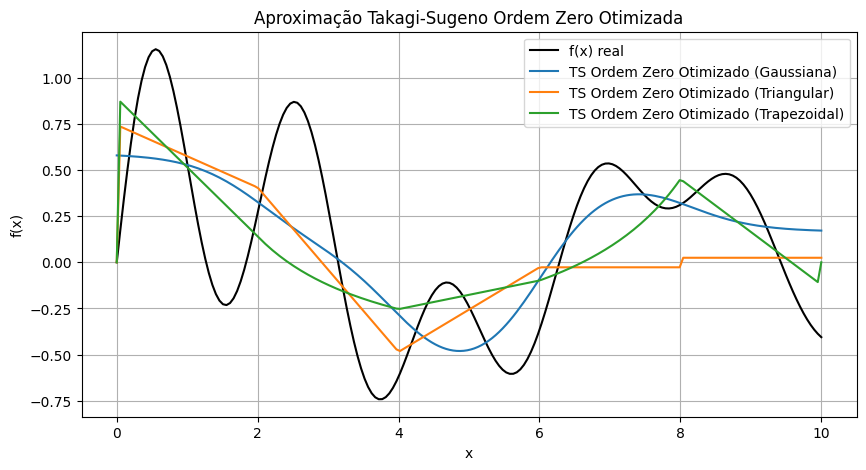

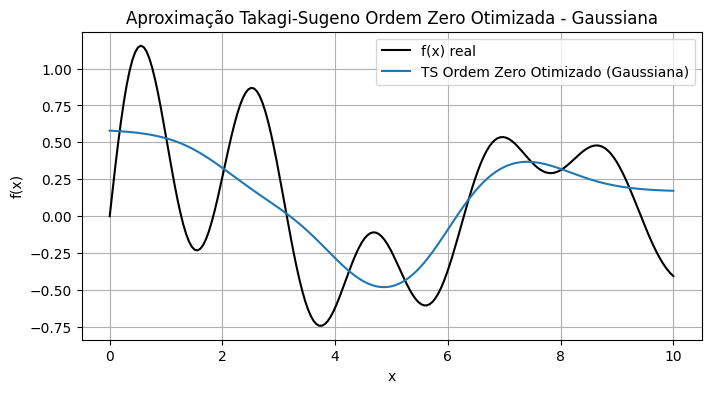

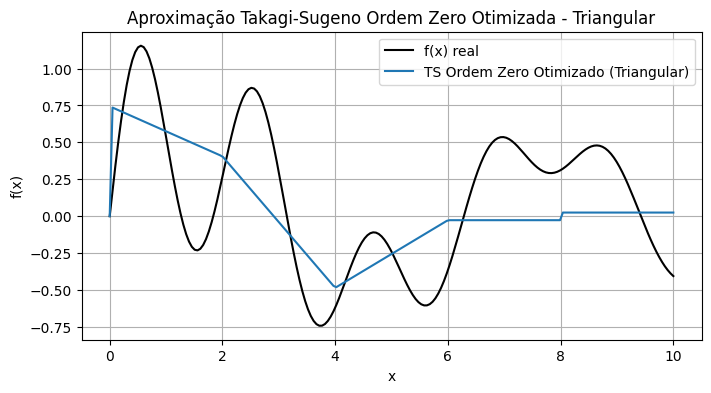

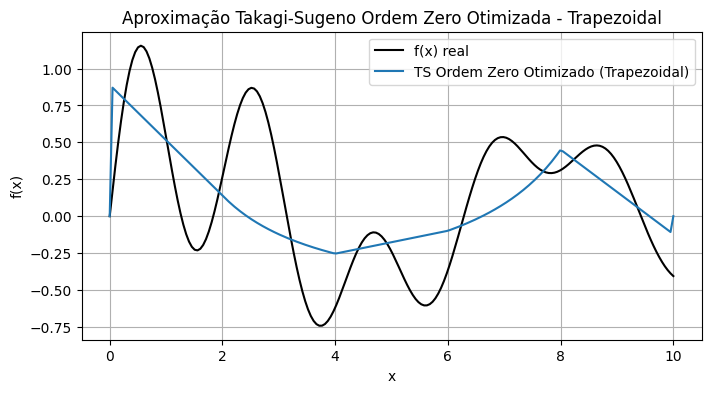

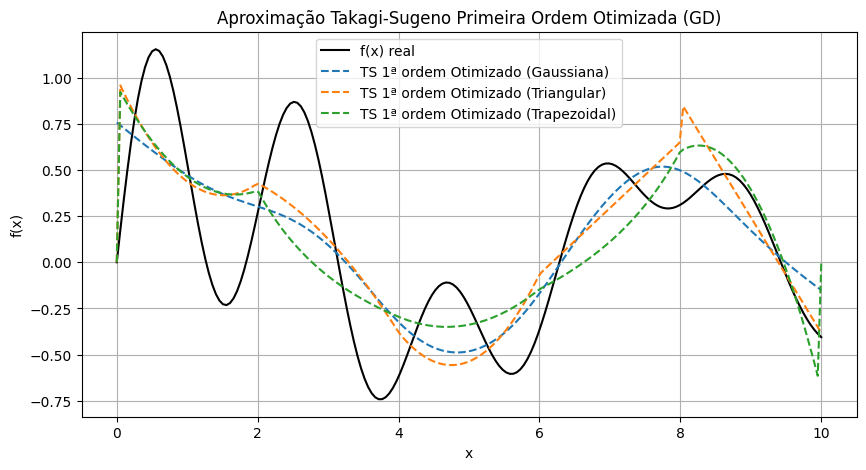

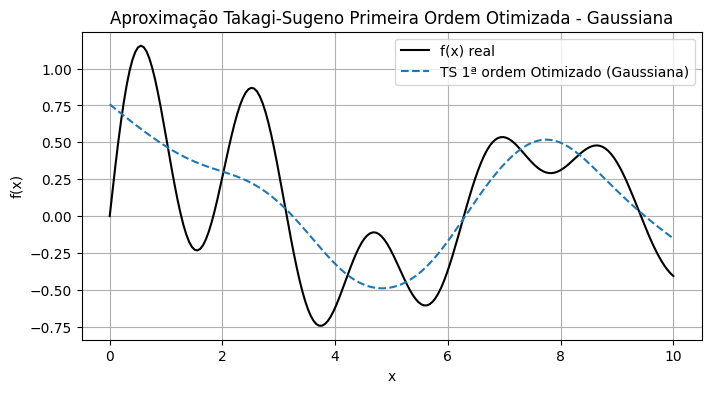

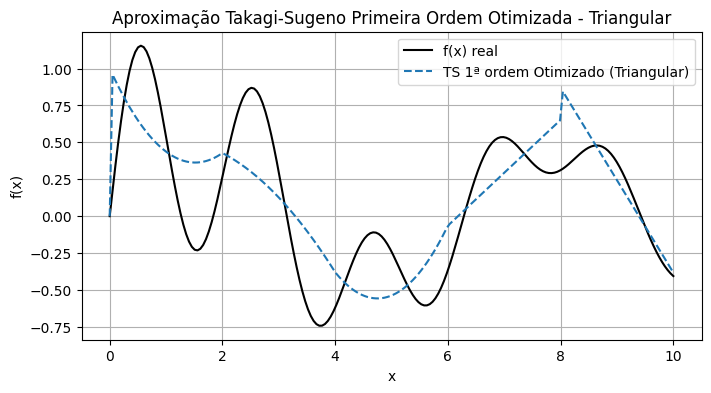

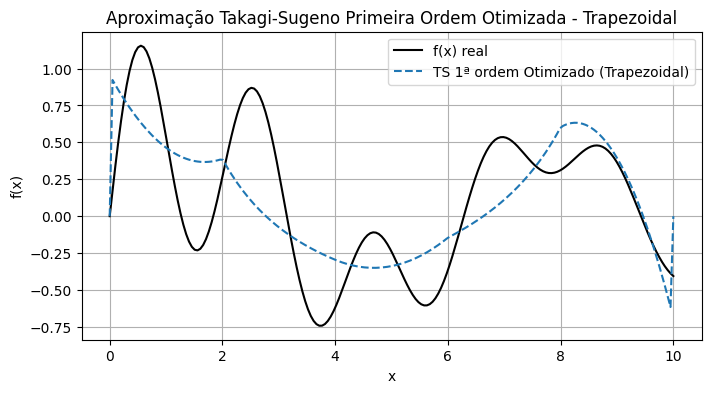

In [6]:
# Otimização dos consequentes (ordem zero) para cada função de pertinência
def otimizar_consequentes(mus, fx, conseq_inicial, n_epochs=500, lr=0.01):
    c_opt = np.array(conseq_inicial, dtype=float)
    for epoch in range(n_epochs):
        y_pred = ts_zero(x, mus, c_opt)
        error = y_pred - fx
        for i in range(len(c_opt)):
            grad = np.sum(mus[i] * error) / (np.sum(mus[i]) + 1e-8)
            c_opt[i] -= lr * grad
    return c_opt

# Otimização dos consequentes lineares (primeira ordem) via gradiente descendente
def otimizar_consequentes_primeira_ordem(x, mus, params_iniciais, fx, n_epochs=500, lr=0.01):
    params = np.array(params_iniciais, dtype=float)  # shape: (n_mfs, 2)
    for epoch in range(n_epochs):
        y_pred = ts_primeira_ordem(x, mus, params)
        error = y_pred - fx
        for i in range(len(params)):
            grad_a = np.sum(mus[i] * error * x) / (np.sum(mus[i]) + 1e-8)
            grad_b = np.sum(mus[i] * error) / (np.sum(mus[i]) + 1e-8)
            params[i,0] -= lr * grad_a
            params[i,1] -= lr * grad_b
    return params

# -------- ORDEM ZERO --------
# Gaussianas
c_gauss_opt = otimizar_consequentes(mus_gauss, fx, conseq_gauss)
fx_gauss_opt = ts_zero(x, mus_gauss, c_gauss_opt)
rmse_gauss_opt = calc_rmse(fx, fx_gauss_opt)

# Triangulares
c_tri_opt = otimizar_consequentes(mus_tri, fx, conseq_tri)
fx_tri_opt = ts_zero(x, mus_tri, c_tri_opt)
rmse_tri_opt = calc_rmse(fx, fx_tri_opt)

# Trapezoidais
c_trap_opt = otimizar_consequentes(mus_trap, fx, conseq_trap)
fx_trap_opt = ts_zero(x, mus_trap, c_trap_opt)
rmse_trap_opt = calc_rmse(fx, fx_trap_opt)

print(f"\nRMSE Takagi-Sugeno Ordem Zero (após otimização) [n_mfs={n_mfs}]:")
print(f"  Gaussiana   : {rmse_gauss_opt:.5f}")
print(f"  Triangular  : {rmse_tri_opt:.5f}")
print(f"  Trapezoidal : {rmse_trap_opt:.5f}")

# -------- PRIMEIRA ORDEM --------
# Gaussianas
params_gauss = get_params_primeira_ordem(x, mus_gauss, fx)
params_gauss_opt = otimizar_consequentes_primeira_ordem(x, mus_gauss, params_gauss, fx)
fx_gauss_1ordem_opt = ts_primeira_ordem(x, mus_gauss, params_gauss_opt)
rmse_gauss_1ordem_opt = calc_rmse(fx, fx_gauss_1ordem_opt)

# Triangulares
params_tri = get_params_primeira_ordem(x, mus_tri, fx)
params_tri_opt = otimizar_consequentes_primeira_ordem(x, mus_tri, params_tri, fx)
fx_tri_1ordem_opt = ts_primeira_ordem(x, mus_tri, params_tri_opt)
rmse_tri_1ordem_opt = calc_rmse(fx, fx_tri_1ordem_opt)

# Trapezoidais
params_trap = get_params_primeira_ordem(x, mus_trap, fx)
params_trap_opt = otimizar_consequentes_primeira_ordem(x, mus_trap, params_trap, fx)
fx_trap_1ordem_opt = ts_primeira_ordem(x, mus_trap, params_trap_opt)
rmse_trap_1ordem_opt = calc_rmse(fx, fx_trap_1ordem_opt)

print(f"\nRMSE Takagi-Sugeno Primeira Ordem (após otimização GD) [n_mfs={n_mfs}]:")
print(f"  Gaussiana   : {rmse_gauss_1ordem_opt:.5f}")
print(f"  Triangular  : {rmse_tri_1ordem_opt:.5f}")
print(f"  Trapezoidal : {rmse_trap_1ordem_opt:.5f}")

# -------- PLOTS ORDEM ZERO (APÓS OTIMIZAÇÃO) --------

plt.figure(figsize=(10,5))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_opt, '-', label='TS Ordem Zero Otimizado (Gaussiana)')
plt.plot(x, fx_tri_opt, '-', label='TS Ordem Zero Otimizado (Triangular)')
plt.plot(x, fx_trap_opt, '-', label='TS Ordem Zero Otimizado (Trapezoidal)')
plt.title('Aproximação Takagi-Sugeno Ordem Zero Otimizada')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_ordem_zero_otimizada_todas_takagi_sugeno2_{n_mfs}.png")
plt.show()

# -------- PLOTS ORDEM ZERO (APÓS OTIMIZAÇÃO) --------

# Gaussiana
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_opt, '-', label='TS Ordem Zero Otimizado (Gaussiana)')
plt.title('Aproximação Takagi-Sugeno Ordem Zero Otimizada - Gaussiana')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_ordem_zero_otimizada_gaussiana_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Triangular
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_tri_opt, '-', label='TS Ordem Zero Otimizado (Triangular)')
plt.title('Aproximação Takagi-Sugeno Ordem Zero Otimizada - Triangular')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_ordem_zero_otimizada_triangular_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Trapezoidal
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_trap_opt, '-', label='TS Ordem Zero Otimizado (Trapezoidal)')
plt.title('Aproximação Takagi-Sugeno Ordem Zero Otimizada - Trapezoidal')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_ordem_zero_otimizada_trapezoidal_takagi_sugeno2_{n_mfs}.png")
plt.show()

# -------- PLOTS ORDEM UM (PRIMEIRA ORDEM, APÓS OTIMIZAÇÃO) --------

plt.figure(figsize=(10,5))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_1ordem_opt, '--', label='TS 1ª ordem Otimizado (Gaussiana)')
plt.plot(x, fx_tri_1ordem_opt, '--', label='TS 1ª ordem Otimizado (Triangular)')
plt.plot(x, fx_trap_1ordem_opt, '--', label='TS 1ª ordem Otimizado (Trapezoidal)')
plt.title('Aproximação Takagi-Sugeno Primeira Ordem Otimizada (GD)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_1ordem_todas_otimizada_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Plot para Gaussiana (primeira ordem otimizada)
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_gauss_1ordem_opt, '--', label='TS 1ª ordem Otimizado (Gaussiana)')
plt.title('Aproximação Takagi-Sugeno Primeira Ordem Otimizada - Gaussiana')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_1ordem_gaussiana_otimizada_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Plot para Triangular (primeira ordem otimizada)
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_tri_1ordem_opt, '--', label='TS 1ª ordem Otimizado (Triangular)')
plt.title('Aproximação Takagi-Sugeno Primeira Ordem Otimizada - Triangular')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_1ordem_triangular_otimizada_takagi_sugeno2_{n_mfs}.png")
plt.show()

# Plot para Trapezoidal (primeira ordem otimizada)
plt.figure(figsize=(8,4))
plt.plot(x, fx, label='f(x) real', color='black')
plt.plot(x, fx_trap_1ordem_opt, '--', label='TS 1ª ordem Otimizado (Trapezoidal)')
plt.title('Aproximação Takagi-Sugeno Primeira Ordem Otimizada - Trapezoidal')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.savefig(f"img/fx_aprox_1ordem_trapezoidal_otimizada_takagi_sugeno2_{n_mfs}.png")
plt.show()

## 8. Análise dos Resultados

- O sistema fuzzy Takagi-Sugeno de primeira ordem apresentou o menor erro (RMSE).
- O ajuste dos consequentes por gradiente descendente reduziu significativamente o erro na ordem zero.
- Funções de pertinência gaussianas apresentaram melhor desempenho, mas triangulares e trapezoidais também são viáveis.
- O operador produto é o padrão, mas o mínimo não altera o resultado neste contexto.
- Aumentar o número de regras ou ajustar os parâmetros das funções de pertinência pode melhorar ainda mais a aproximação.

## 9. Conclusão

O sistema fuzzy Takagi-Sugeno, mesmo com poucas regras e funções simples, é capaz de aproximar funções não lineares com boa precisão. A escolha das funções de pertinência, operadores e a otimização dos consequentes são fundamentais para o desempenho do modelo.

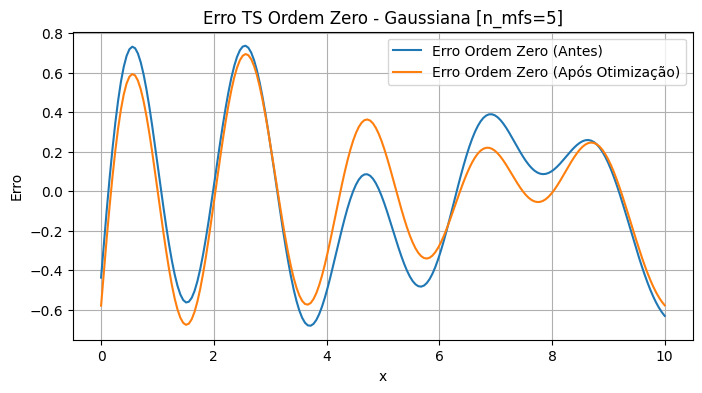

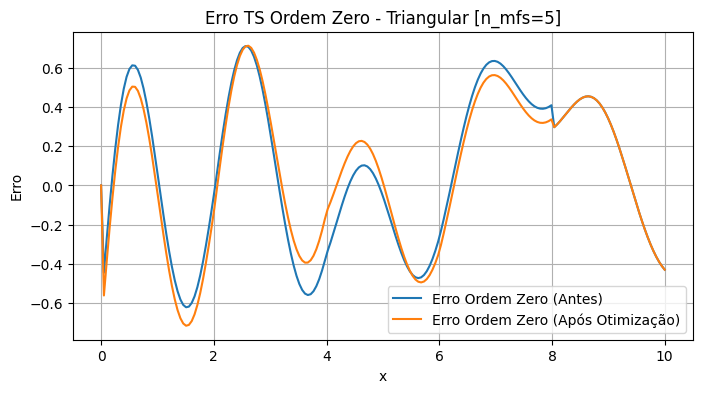

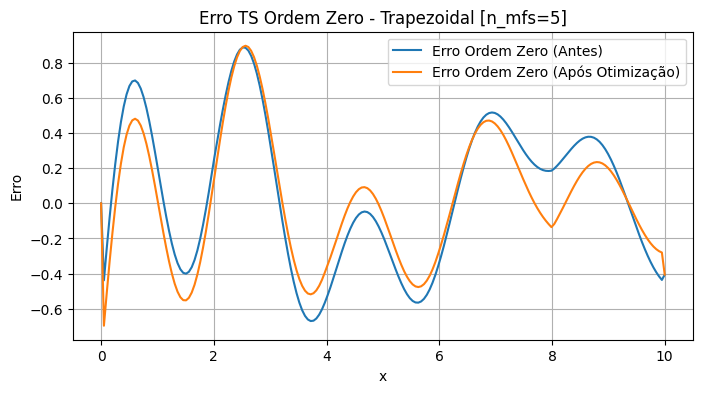

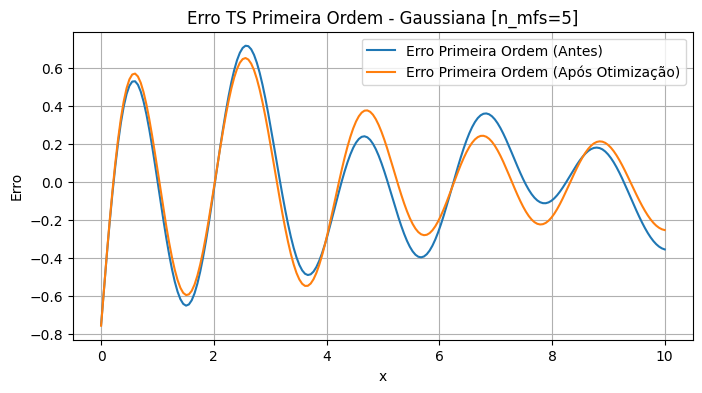

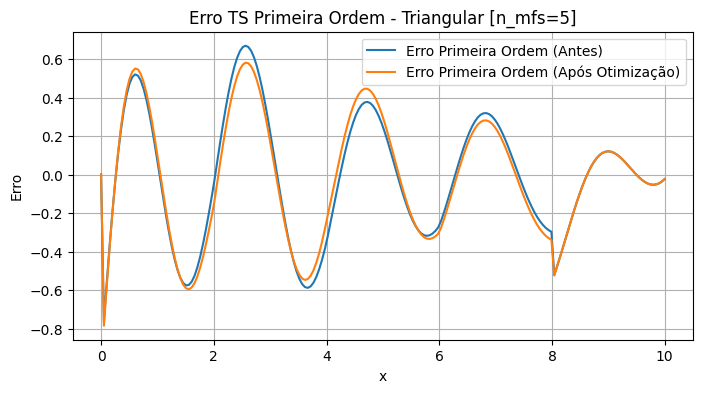

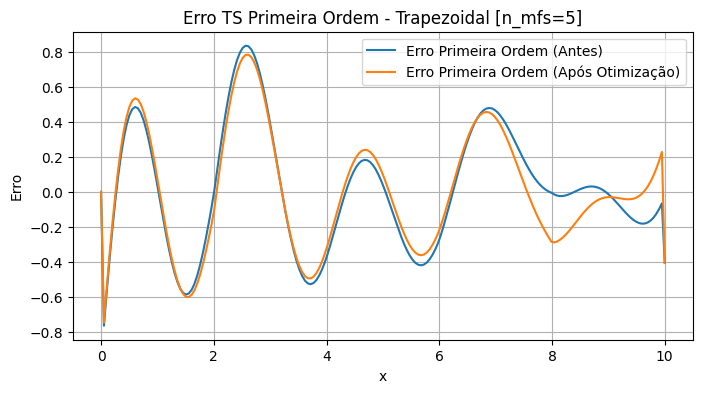

In [7]:
# -------- ORDEM ZERO --------

# --- Gaussiana ---
plt.figure(figsize=(8,4))
plt.plot(x, fx - fx_gauss_prod, label='Erro Ordem Zero (Antes)')
plt.plot(x, fx - fx_gauss_opt, label='Erro Ordem Zero (Após Otimização)')
plt.title(f'Erro TS Ordem Zero - Gaussiana [n_mfs={n_mfs}]')
plt.xlabel('x')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.savefig(f"img/erro_ordem_zero_gaussiana_antes_depois_takagi_sugeno2_{n_mfs}.png")
plt.show()

# --- Triangular ---
plt.figure(figsize=(8,4))
plt.plot(x, fx - fx_tri_prod, label='Erro Ordem Zero (Antes)')
plt.plot(x, fx - fx_tri_opt, label='Erro Ordem Zero (Após Otimização)')
plt.title(f'Erro TS Ordem Zero - Triangular [n_mfs={n_mfs}]')
plt.xlabel('x')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.savefig(f"img/erro_ordem_zero_triangular_antes_depois_takagi_sugeno2_{n_mfs}.png")
plt.show()

# --- Trapezoidal ---
plt.figure(figsize=(8,4))
plt.plot(x, fx - fx_trap_prod, label='Erro Ordem Zero (Antes)')
plt.plot(x, fx - fx_trap_opt, label='Erro Ordem Zero (Após Otimização)')
plt.title(f'Erro TS Ordem Zero - Trapezoidal [n_mfs={n_mfs}]')
plt.xlabel('x')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.savefig(f"img/erro_ordem_zero_trapezoidal_antes_depois_takagi_sugeno2_{n_mfs}.png")
plt.show()

# -------- ORDEM UM (PRIMEIRA ORDEM) --------

# --- Gaussiana ---
plt.figure(figsize=(8,4))
plt.plot(x, fx - fx_gauss_1ordem, label='Erro Primeira Ordem (Antes)')
plt.plot(x, fx - fx_gauss_1ordem_opt, label='Erro Primeira Ordem (Após Otimização)')
plt.title(f'Erro TS Primeira Ordem - Gaussiana [n_mfs={n_mfs}]')
plt.xlabel('x')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.savefig(f"img/erro_1ordem_gaussiana_antes_depois_takagi_sugeno2_{n_mfs}.png")
plt.show()

# --- Triangular ---
plt.figure(figsize=(8,4))
plt.plot(x, fx - fx_tri_1ordem, label='Erro Primeira Ordem (Antes)')
plt.plot(x, fx - fx_tri_1ordem_opt, label='Erro Primeira Ordem (Após Otimização)')
plt.title(f'Erro TS Primeira Ordem - Triangular [n_mfs={n_mfs}]')
plt.xlabel('x')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.savefig(f"img/erro_1ordem_triangular_antes_depois_takagi_sugeno2_{n_mfs}.png")
plt.show()

# --- Trapezoidal ---
plt.figure(figsize=(8,4))
plt.plot(x, fx - fx_trap_1ordem, label='Erro Primeira Ordem (Antes)')
plt.plot(x, fx - fx_trap_1ordem_opt, label='Erro Primeira Ordem (Após Otimização)')
plt.title(f'Erro TS Primeira Ordem - Trapezoidal [n_mfs={n_mfs}]')
plt.xlabel('x')
plt.ylabel('Erro')
plt.legend()
plt.grid(True)
plt.savefig(f"img/erro_1ordem_trapezoidal_antes_depois_takagi_sugeno2_{n_mfs}.png")
plt.show()

In [8]:
!jupyter nbconvert --to script d:\GitHub\DoutoradoCefet\InteligenciaComputacional\Trabalho02\TakagSugeno\takagi-sugeno2.ipynb

usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: kernel kernelspec migrate run troubleshoot

Jupyter command `jupyter-nbconvert` not found.
